In [2]:
#+++ версия 2025.04.14 tg: Цифриум, команда 2 Машинисты, @codeup1054, @Kimutogo,@Eques8, @serin_1995, @saturnian1, @tyuop077
from importlib import reload
import sys, os 

current_dir = os.getcwd()

for i in ['utils_log','datetime','glob']:
    if i in sys.modules: del  sys.modules[i] 
    exec (f'from {i} import *')  
    
    
tm()

i = 0
for k in dir(ps):
    if ('_' not in k) and isinstance(getattr(ps, k), str) :
        print (f"{getattr(ps, k)}{k:^9}{ps._} ", end="")
        if (i := i+1)%8 == 0 : print("")

dfr = dfr if 'dfr' in vars() else {}
tm('\n>>>')   



 *** Start at: 10:48:31 2025-04-25  ****************************************
  BBLUE     BGRAY    BGREEN    BLBLUE    BLCYAN    BLGRAY    BLGREEN   BLILAC   
 BLLBLUE  BLMAGENTA   BLRED     BLUE       BLY    BLYELLOW  BMAGENTA    BOLD    
 BORANGE    BRED       BY      BYELLOW    CYAN    DARKCYAN      E        END    
   ERR      GRAY      GREEN     LBLUE     LGRAY    LGREEN   LMAGENTA    LRED    
 MAGENTA   ORANGE    PURPLE      RED        T       TOTAL   UNDERLINE     Y     
 YELLOW      err      0:00:00.001  ₀⡄₀₀⡄₀₀.₀₀₁ 
>>>


datetime.datetime(2025, 4, 25, 10, 48, 31, 220024)

### 00. поиск файлов

In [20]:
import glob
keyframes_mask = r'lectures_2025\Общественное движение в России 2четверь XIX в_01\keyframes\*'
keyframes = glob.glob(keyframes_mask)
keyframes

['lectures_2025\\Общественное движение в России 2четверь XIX в_01\\keyframes\\keyframe_01.jpg',
 'lectures_2025\\Общественное движение в России 2четверь XIX в_01\\keyframes\\keyframe_02.jpg',
 'lectures_2025\\Общественное движение в России 2четверь XIX в_01\\keyframes\\keyframe_03.jpg',
 'lectures_2025\\Общественное движение в России 2четверь XIX в_01\\keyframes\\keyframe_04.jpg',
 'lectures_2025\\Общественное движение в России 2четверь XIX в_01\\keyframes\\keyframe_05.jpg']

### 01. распознавание слайда без разбиения на блоки 

Такого распознавания вполне достаточно чтобы пождмешать слова в промпт

In [61]:
from PIL import Image
import pytesseract

# Если нужно — раскомментируй и укажи путь
# pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

image_path = r'lectures_2025\Общественное движение в России 2четверь XIX в_01\keyframes\keyframe_03.jpg'

img = Image.open(image_path).convert("RGB")
text = pytesseract.image_to_string(img, lang='rus')
print("📄 Распознанный текст:\n")
print(text)

📄 Распознанный текст:

Общественные движения во второй четверти ХИХ в.

|

либеральное

|

западники

Основные идеи:

Мировая цивилизация едина, вычленение из неё какой-либо страны ведёт к загниванию.
Задача России — примкнуть к Западу и образовать «единую общечеловеческую культурную семью»

Вопрос о форме государства:

Ограниченная монархия, законодательный
парламент, демократические свободы



### 03. распознавание слайда с разбиением на блоки 

Требует точных настроек корнтрастности, яркости, на практике этот вариант сложно быдет применять

📋 Найдено блоков текста: 13


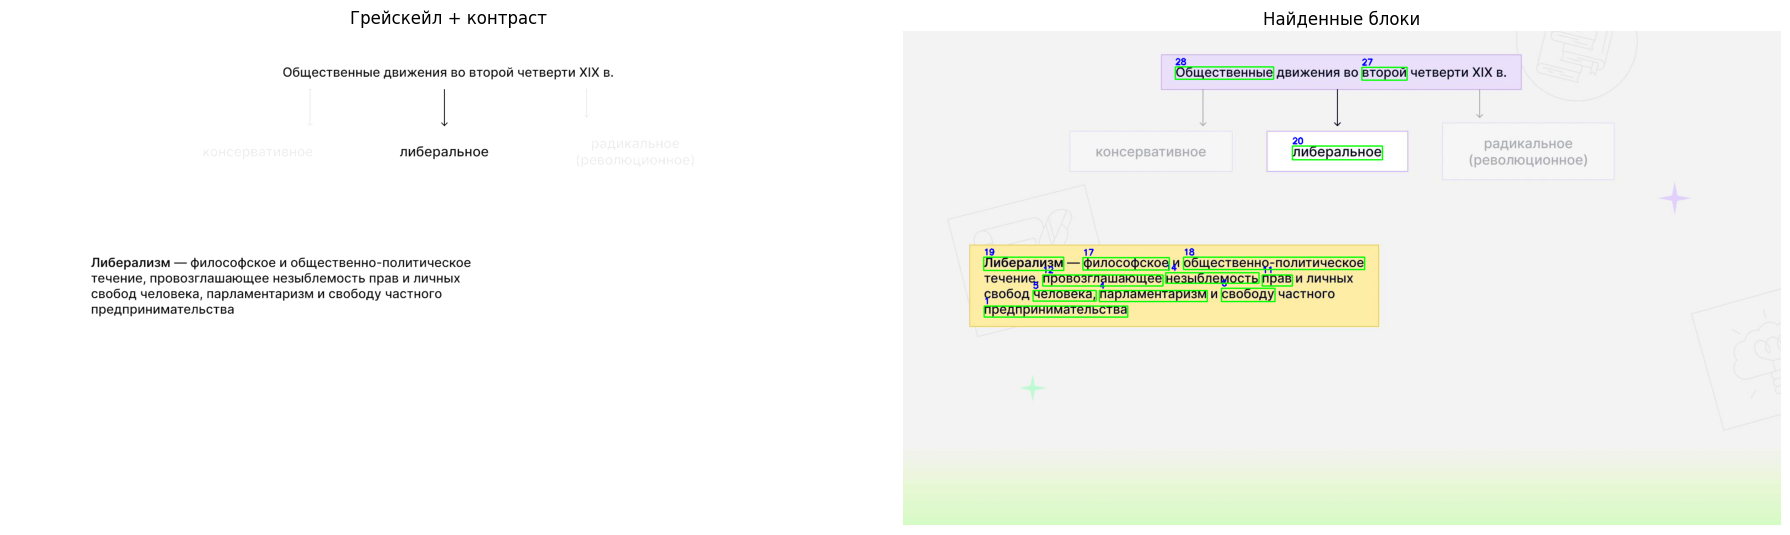

1   | предпринимательства
2   | парламентаризм
3   | человека,
4   | свободу
5   | прав
6   | провозглашающее
7   | незыблемость
8   | философское
9   | общественно-политическое
10  | Либерализм
11  | либеральное
12  | второй
13  | Общественные


In [13]:
import os
import cv2
import pytesseract
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt

tesseract_path = r'C:\Program Files\Tesseract-OCR\tesseract.exe' # Пример

pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

def ocr_block_2(image_path, alpha=1.1, beta=50, min_width=100, min_height=30):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Файл не найден: {image_path}")

    # img = cv2.imread(image_path)

    pil_image = Image.open(image_path)
    img = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
    
    if img is None:
        raise ValueError("Ошибка при загрузке изображения")

    original = img.copy()

    # Грейскейл и осветление
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    adjusted = cv2.convertScaleAbs(gray, alpha=alpha, beta=beta)

    # Размытие и порог
    blurred = cv2.GaussianBlur(adjusted, (3, 3), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Морфология
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 3))
    dilated = cv2.dilate(thresh, kernel, iterations=1)

    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    result_img = original.copy()
    recognized_blocks = []

    for n, cnt in enumerate(contours):
        x, y, w, h = cv2.boundingRect(cnt)

        if w < min_width or h < min_height:
            continue

        roi = img[y:y+h, x:x+w]
        roi_pil = Image.fromarray(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
        text = pytesseract.image_to_string(roi_pil, lang='rus').strip()

        if text:
            recognized_blocks.append(((x, y, w, h), text))
            cv2.rectangle(result_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(result_img, f"{n+1}", (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    records = [
        {"id": i + 1, "text": text, "x": x, "y": y}
        for i, ((x, y, w, h), text) in enumerate(recognized_blocks)
    ]

    print(f"📋 Найдено блоков текста: {len(records)}")

    # Показываем этапы
    plt.figure(figsize=(18, 6))
    
    # plt.subplot(1, 3, 1)
    
    # plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    # plt.title("Оригинал")
    # plt.axis("off")
    
    plt.subplot(1, 2, 1)
    plt.imshow(adjusted, cmap='gray')
    plt.title("Грейскейл + контраст")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.title("Найденные блоки")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

    return records


fname = '02.jpg'
fname = r'lectures_2025\Общественное движение в России 2четверь XIX в_01\keyframes\keyframe_03.jpg'

blocks = ocr_block_2(
    fname,
    alpha=1.1,
    beta=50,
    min_width=20,
    min_height=20
)

for b in blocks:
    print(f"{b['id']:<3} | {b['text']}") 

In [ ]:
{'id': 1, 'text': 'демократические', 'x': 328, 'y': 902}